# Filter protein-ligand complex dataset
2022-9-8, Jue

I did a few things below to prepare the protein-ligand training data for RF2-allatom:

1. Remove training examples where the ligand is on the surface or far away from protein.

2. Remove GPCRs from main training data csv, so we can evaluate the model on GPCR docking after training and hyperparameter selection.

    Frank sent some references for the GPCR Dock competition, which mention some GPCR+ligand complexes that were used as a community-wide benchmark:
     - GPCR Dock 2008: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2728591/ (3eml)
     - GPCR Dock 2010: https://pubmed.ncbi.nlm.nih.gov/21827947/ (3pbl, 3oeu, 3oe0, 3oe6, 3oe8, 3oe9)
     - GPCR Dock 2013: https://pubmed.ncbi.nlm.nih.gov/25066135/ (4IB4, 4IAR, 4IAQ, 4jkv, 4N4W, 4QIM, 4QIN)
     - For 2021, 7vug/7vuh and 7vgx were two of the targets used. the other 3 are still unpublished (as far as I know)
     
3. Make list of test set clusters based on Ivan's previous choice of test set (astex + maybe others) as well as include the GPCR Dock targets. These will be excluded from both train and valid sets for protein/sm complex and protein datasets


Notes on training data:

 1. Ivan's original training set, only examples with ligands: `/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly.csv`
 2. Ivan's training set with test examples removed (astex + others?): `/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly_notest.csv`
 3. Rohith's protein/ligand training set (like #2 but filtering out things that openbabel can't load, and adding a path to mol2 files): `/projects/ml/RF2_allatom/list_v02_ligonly_notest_ccd_ob`

## Imports

In [1]:
import pandas as pd
import torch
import openbabel

import sys

sys.path.insert(0,'/home/jue/git/bff/RF2_allatom/')
from util import aa2num, atomnum2atomtype

import glob

/home/jue/.conda/envs/SE3nv/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Calculate contacts

In [13]:
df = pd.read_csv('/projects/ml/RF2_allatom/list_v02_ligonly_notest_ccd_ob',dtype=str)

In [14]:
df.shape

(56186, 9)

In [16]:
df['CLUSTER'].drop_duplicates().shape

(7272,)

In [50]:
# disable openbabel warnings
from openbabel import openbabel as ob
ob.obErrorLog.SetOutputLevel(0)

In [51]:
records = []
    
for i,row in df.iterrows():

    # load protein
    pdb = torch.load('/projects/ml/TrRosetta/PDB-2021AUG02/torch/pdb/'+row['CHAINID'][1:3]+'/'+row['CHAINID']+'.pt')
    xyz_prot = pdb['xyz'][pdb['mask'].bool()]

    # loop over ligands
    sm_chains = eval(row['LIGANDS'])
    for sm_chain in sm_chains:

        filename = "/home/dimaio/ccd/by-pdb/"+row['CHAINID'][1:3]+"/"+sm_chain

        # load small molecule
        obConversion = openbabel.OBConversion()
        obConversion.SetInFormat("mol2")

        obmol = openbabel.OBMol()
        obConversion.ReadFile(obmol,filename)
        obmol.DeleteHydrogens()
        # msa = torch.tensor([aa2num[atomnum2atomtype[obmol.GetAtom(i).GetAtomicNum()]] for i in range(1, obmol.NumAtoms()+1)])
        atoms = [(i, obmol.GetAtom(i).GetAtomicNum()) for i in range(1, obmol.NumAtoms()+1)]
        atoms = [(i, a) for (i,a) in atoms if a != 1] # filter out hydrogens that sometimes still get through
        msa = torch.tensor([aa2num[atomnum2atomtype[a]] for (i,a) in atoms])
        ins = torch.zeros_like(msa)
        xyz_sm = torch.tensor([[obmol.GetAtom(i).x(),obmol.GetAtom(i).y(), obmol.GetAtom(i).z()] for i,a in atoms])

        # count contacts
        dist = torch.sqrt(torch.square(xyz_prot[:,None] - xyz_sm[None]).sum(-1))
        n_contacts = torch.sum(dist<5)

        records.append(dict(
            CHAINID = row['CHAINID'],
            LIGAND = sm_chain,
            NUM_CONTACTS = int(n_contacts)
        ))

In [52]:
df2 = pd.DataFrame.from_records(records)

In [53]:
df2.shape

(77481, 3)

In [84]:
df2 = df2.merge(df[['CHAINID','CLUSTER']],on='CHAINID',how='left')

In [85]:
df2.to_csv('list_v02_ligonly_notest_ccd_ob_contacts.csv')

## Filter

In [18]:
df2 = pd.read_csv('list_v02_ligonly_notest_ccd_ob_contacts.csv',index_col=0)

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/jue/.conda/envs/SE3nv/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


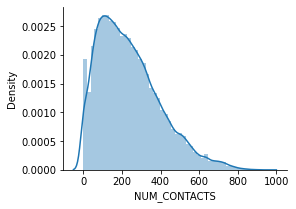

In [73]:
fig,ax = plt.subplots(figsize=(4,3))
sns.distplot(df2['NUM_CONTACTS'],ax=ax)
sns.despine()

In [75]:
fig.savefig('contacts_hist.png',dpi=300,bbox_inches='tight')

In [35]:
df2.shape

(77481, 4)

In [37]:
df2.drop_duplicates('CLUSTER').shape

(7272, 4)

In [38]:
df2[df2['NUM_CONTACTS']>=10].shape

(75276, 4)

In [39]:
df2[df2['NUM_CONTACTS']>=10].drop_duplicates('CLUSTER').shape

(7197, 4)

I looked at some examples with 0, 1, 5, or 10 contacts, and only the 10-contact example looked good, so using this as a minimum cutoff

In [19]:
filt = df2[df2['NUM_CONTACTS']>=10]

In [20]:
records = []
for chainid in filt['CHAINID'].drop_duplicates():
    tmp = filt[filt['CHAINID']==chainid]
    records.append(dict(
        CHAINID = chainid,
        LIGANDS = list(tmp['LIGAND']),
        CONTACTS = list(tmp['NUM_CONTACTS'])
    ))

In [21]:
filt_ligands = pd.DataFrame.from_records(records)

In [22]:
filt_ligands.shape

(55258, 3)

In [23]:
df_new = df[[col for col in df.columns 
             if col != 'LIGANDS' and col != 'CONTACTS']] \
         .merge(filt_ligands, on='CHAINID', how='right')

In [24]:
df_new.shape

(55258, 9)

Make sure columns are in same order as original list

In [25]:
df_new = df_new[df.columns]

In [26]:
df_new.shape

(55258, 9)

In [27]:
df_new.to_csv('list_v02_sm_filt.csv',index=None)

Remove clusters containing GPCRs from the GPCR Dock competitions 2008, 2010, 2013, and 2021

In [28]:
import numpy as np

In [29]:
df_new = pd.read_csv('list_v02_sm_filt.csv',index_col=None,dtype=str)

In [30]:
gpcrs = ['3eml', '3pbl', '3oeu', '3oe0', '3oe6', '3oe8', '3oe9', '4ib4', '4iar', '4iaq', '4jkv', '4n4w', '4qim', '4qin',
         '7vug', '7vuh', '7vgx']

In [31]:
mask = np.any([df_new['CHAINID'].str.contains(x) for x in gpcrs], axis=0)

In [32]:
df_gpcr = df_new[mask]

In [33]:
df_gpcr.shape

(12, 9)

In [34]:
df_new = df_new[~df_new['CLUSTER'].isin(df_gpcr['CLUSTER'].values)]

In [35]:
df_new.shape

(55129, 9)

This is the filtered dataset we will use for training.

In [37]:
df_new.shape

(55129, 9)

In [38]:
df_new.to_csv('list_v02_sm_filt_notest.csv',index=None)

## Test set
Put astex and gpcr clusters in a list, to be used to exclude examples from training and validation in other datasets (PDB monomer, etc)

Ivan's original training set, only examples with ligands

In [71]:
orig = pd.read_csv('/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly.csv')

In [72]:
orig.shape

(78711, 9)

Ivan's training set with test examples removed (astex + others?)

In [73]:
notest = pd.read_csv('/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly_notest.csv')

In [74]:
notest.shape

(66863, 9)

Clusters that are in test set

In [75]:
test_clus = np.setdiff1d(orig['CLUSTER'].drop_duplicates(), notest['CLUSTER'].drop_duplicates())

In [76]:
test_clus.shape

(48,)

In [92]:
test_clus

array([  321,   430,   725,   950,  1694,  2767,  2798,  3102,  3233,
        4285,  4736,  4935,  5300,  6840,  7324,  7436,  7757,  8667,
        9249,  9276, 11050, 12969, 14163, 14175, 15132, 15643, 15961,
       16646, 16713, 16823, 18013, 19157, 21149, 21673, 22651, 23531,
       23791, 24229, 24539, 25542, 25637, 25830, 25841, 25867, 26519,
       26885, 27044, 27679])

Hashes (PDB entries) that are in test set

In [77]:
test_hash = np.setdiff1d(orig['HASH'].drop_duplicates(), notest['HASH'].drop_duplicates())

In [78]:
test_hash.shape

(2905,)

PDB chains that are in test set

In [79]:
orig_test = orig[~orig['CHAINID'].isin(notest['CHAINID'].values)]

In [80]:
orig_test.shape

(11848, 9)

Current `lig_test` file contains 16787 entries that are integers. Not sure how that corresponds to the info in these tables.

We will make a new list `sm_heldout_test_clusters` containing the cluster IDs of Ivan's test examples, plus the GPCRs from above.

In [93]:
df_gpcr['CLUSTER'].drop_duplicates()

2899     24395
5127      6005
8013     20696
46754    21380
Name: CLUSTER, dtype: int64

In [90]:
all_test_clus = np.unique(np.concatenate([test_clus,df_gpcr['CLUSTER']]))

In [91]:
all_test_clus

array([  321,   430,   725,   950,  1694,  2767,  2798,  3102,  3233,
        4285,  4736,  4935,  5300,  6005,  6840,  7324,  7436,  7757,
        8667,  9249,  9276, 11050, 12969, 14163, 14175, 15132, 15643,
       15961, 16646, 16713, 16823, 18013, 19157, 20696, 21149, 21380,
       21673, 22651, 23531, 23791, 24229, 24395, 24539, 25542, 25637,
       25830, 25841, 25867, 26519, 26885, 27044, 27679])

In [94]:
with open('sm_test_heldout_test_clusters.txt','w') as outf:
    for i in all_test_clus:
        print(i, file=outf)

## Bad examples
This is just to document some bad examples that I saw when preparing the above.

### Hydrogen that can't be removed
TODO:
 - How many of these are there?
 - Do these come from non-H atoms in the input file? In this case we should set them to unknown (ATM) rather than removing

In [59]:
filename = '/home/dimaio/ccd/by-pdb/wv/6wv5_UAV_1_A_401__B___.mol2'

# load small molecule
obConversion = openbabel.OBConversion()
obConversion.SetInFormat("mol2")

obmol = openbabel.OBMol()
obConversion.ReadFile(obmol,filename)
obmol.DeleteHydrogens()

# old code: should error
msa = torch.tensor([aa2num[atomnum2atomtype[obmol.GetAtom(i).GetAtomicNum()]] for i in range(1, obmol.NumAtoms()+1)])

KeyError: 1

In [58]:
# new code that filters out hydrogen
atoms = [(i, obmol.GetAtom(i).GetAtomicNum()) for i in range(1, obmol.NumAtoms()+1)]
atoms = [(i, a) for (i,a) in atoms if a != 1] # filter out hydrogens that sometimes still get through
msa = torch.tensor([aa2num[atomnum2atomtype[a]] for (i,a) in atoms])

In [51]:
ins = torch.zeros_like(msa)
xyz_sm = torch.tensor([[obmol.GetAtom(i).x(),obmol.GetAtom(i).y(), obmol.GetAtom(i).z()] for i,a in atoms])

# count contacts
dist = torch.sqrt(torch.square(xyz_prot[:,None] - xyz_sm[None]).sum(-1))
n_contacts = torch.sum(dist<5)

records.append(dict(
    CHAINID = row['CHAINID'],
    LIGAND = sm_chain,
    NUM_CONTACTS = n_contacts
))

# Scratch

In [ ]:
    mask = torch.full(atom_coords.shape[:-1], True)
    try:
        automorphs = openbabel.vvpairUIntUInt()
        openbabel.FindAutomorphisms(obmol,automorphs)
        atom_coords = atom_coords[torch.tensor(automorphs)[:, :, 1]]
        mask = mask[torch.tensor(automorphs)[:, :, 1]]
    except:
        atom_coords = atom_coords.unsqueeze(0)
        mask = mask.unsqueeze(0)
        print(f"ERROR: automorphs for {filename} yielded invalid tensor")

In [ ]:
    obConversion = openbabel.OBConversion()
    obConversion.SetInFormat("mol2")

    obmol = openbabel.OBMol()
    obConversion.ReadFile(obmol,filename)
    obmol.DeleteHydrogens()
    msa = torch.tensor([aa2num[atomnum2atomtype[obmol.GetAtom(i).GetAtomicNum()]] for i in range(1, obmol.NumAtoms()+1)])
    ins = torch.zeros_like(msa)
    atom_coords = torch.tensor([[obmol.GetAtom(i).x(),obmol.GetAtom(i).y(), obmol.GetAtom(i).z()] for i in range(1, obmol.NumAtoms()+1)])
    mask = torch.full(atom_coords.shape[:-1], True)
    try:
        automorphs = openbabel.vvpairUIntUInt()
        openbabel.FindAutomorphisms(obmol,automorphs)
        atom_coords = atom_coords[torch.tensor(automorphs)[:, :, 1]]
        mask = mask[torch.tensor(automorphs)[:, :, 1]]
    except:
        atom_coords = atom_coords.unsqueeze(0)
        mask = mask.unsqueeze(0)
        print(f"ERROR: automorphs for {filename} yielded invalid tensor")